In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df.head()

,x,y
0,1.409445,5.275026
1,-9.337377,212.625146
2,-6.951291,124.721516
3,3.781497,20.279580
4,-5.841269,93.034061


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1000 non-null   float64
 1   y       1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [5]:
x=df[['x']]
y=df['y']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
df.corr()

,x,y
x,1.000000,-0.283791
y,-0.283791,1.000000


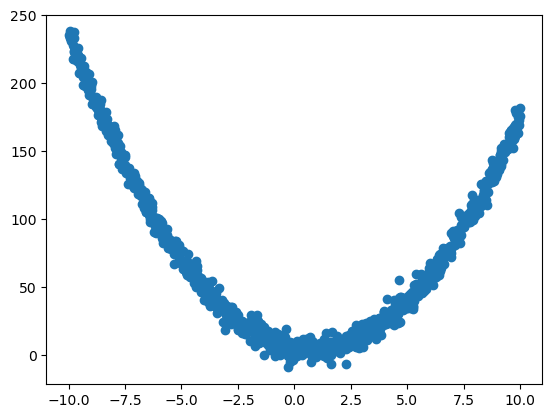

In [8]:
plt.scatter(df['x'],df['y'])

In [9]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
model.intercept_

np.float64(73.52996637048655)

In [11]:
model.coef_

array([-3.32491708])

In [12]:
pred_y_train=model.predict(x_train)

In [13]:
train_error=y_train-pred_y_train
train_error

29     -31.432633
535    118.043749
695    -27.905865
557    -70.908428
836     91.917264
          ...    
106    -23.575383
270    -29.557728
860    -44.453691
435    -35.994277
102     52.513414
Name: y, Length: 800, dtype: float64

In [14]:
pred_y_test=model.predict(x_test)

In [15]:
test_error=y_test-pred_y_test
test_error

521    96.456595
737    49.804413
740   -38.061651
660   -50.799606
411    94.553137
         ...    
408   -47.313657
332    86.665845
208    55.244698
613   -13.910170
78    -44.459539
Name: y, Length: 200, dtype: float64

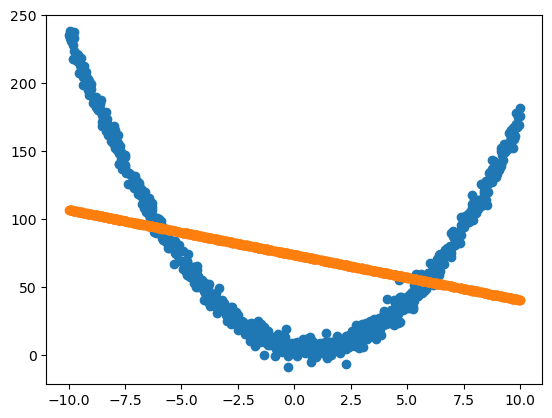

In [16]:
plt.scatter(x_train,y_train)
plt.scatter(x_train,pred_y_train)

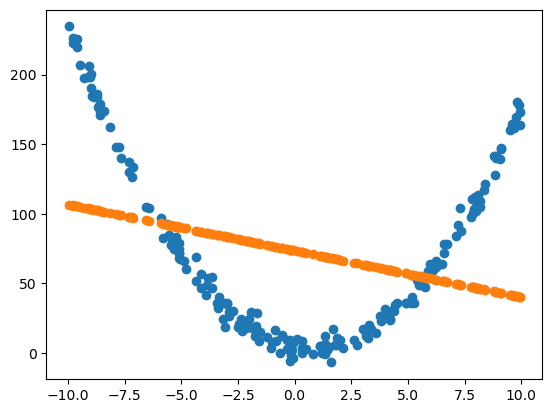

In [17]:
plt.scatter(x_test,y_test)
plt.scatter(x_test,pred_y_test)

In [18]:
r2_score(y_train,pred_y_train)*100

9.350909765393666

In [19]:
r2_score(y_test,pred_y_test)*100

2.7678434749723646

In [20]:
mean_absolute_error(y_train,pred_y_train)*100

5228.061299810079

In [21]:
mean_absolute_error(y_test,pred_y_test)*100

5508.839757640162

In [22]:
root_mean_squared_error(y_train,pred_y_train)*100

6051.282861631312

In [23]:
root_mean_squared_error(y_test,pred_y_test)*100

6353.770772200994

* SInce r2 score is 9.35% for train data and 2.76% for test data we cannot use it for future prediction hence we use polynomial features and then again use linear regression model

In [24]:
from sklearn.preprocessing import PolynomialFeatures

In [25]:
poly=PolynomialFeatures(degree=2)

In [26]:
updated_xtrain=poly.fit_transform(x_train)

In [28]:
updated_xtest=poly.transform(x_test)

In [30]:
model=LinearRegression()
model.fit(updated_xtrain,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred_train=model.predict(updated_xtrain)

In [32]:
y_pred_test=model.predict(updated_xtest)

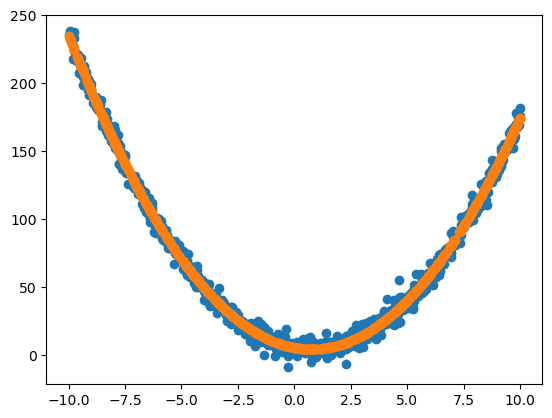

In [33]:
plt.scatter(updated_xtrain[:,1],y_train)
plt.scatter(updated_xtrain[:,1],y_pred_train)

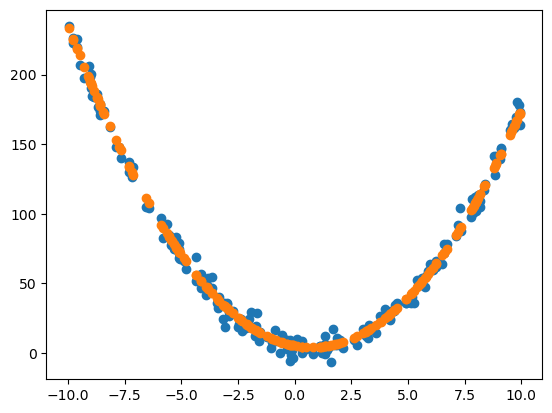

In [35]:
plt.scatter(updated_xtest[:,1],y_test)
plt.scatter(updated_xtest[:,1],y_pred_test)

In [36]:
r2_score(y_train,y_pred_train)*100

99.45285017368587

In [37]:
r2_score(y_test,y_pred_test)*100

99.36856235778967

In [39]:
mean_absolute_error(y_train,y_pred_train)

3.741732583280132

In [40]:
mean_absolute_error(y_test,y_pred_test)

4.097019220324605

In [41]:
root_mean_squared_error(y_train,y_pred_train)

4.701309707003634

In [42]:
root_mean_squared_error(y_test,y_pred_test)

5.120257678721406